# Jaguar Re-ID — Linear Model (Baseline)

**Architecture**: Flatten → Dense(31, softmax)  
**No augmentation, no regularization** — pure baseline to establish a lower bound.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from datetime import datetime

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, optimizers, callbacks
from sklearn.preprocessing import normalize

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

TensorFlow: 2.20.0
GPU: []


In [2]:
PROJECT_ROOT  = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_DIR      = os.path.join(PROJECT_ROOT, 'data')
CLEANED_DIR   = os.path.join(DATA_DIR, 'cleaned')
TRAIN_IMG_DIR = os.path.join(CLEANED_DIR, 'train')
TEST_IMG_DIR  = os.path.join(CLEANED_DIR, 'test')
OUTPUT_DIR    = os.path.join(PROJECT_ROOT, 'outputs')
SUBMISSION_DIR = os.path.join(PROJECT_ROOT, 'submissions')
LOG_DIR = r'C:\tf\logs'

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(SUBMISSION_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

IMG_SIZE    = 224
NUM_CLASSES = 31
BATCH_SIZE  = 32
SEED        = 42

tf.random.set_seed(SEED)
np.random.seed(SEED)

## 1. Data loading

In [3]:
train_df      = pd.read_csv(os.path.join(CLEANED_DIR, 'train_split.csv'))
val_df        = pd.read_csv(os.path.join(CLEANED_DIR, 'val_split.csv'))
test_pairs_df = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'))

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test pairs: {len(test_pairs_df)}")
print(f"Classes: {NUM_CLASSES}")

Train: 1516 | Val: 379 | Test pairs: 137270
Classes: 31


In [4]:
def make_dataset(df, img_dir, training=False):
    paths  = [os.path.join(img_dir, fn) for fn in df['filename']]
    labels = df['label'].values.tolist()

    def load_image(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_png(img, channels=3)
        img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
        img = tf.cast(img, tf.float32) / 255.0
        return img, label

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.shuffle(buffer_size=2000, seed=SEED)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

print("Building train/val datasets (lazy — no full RAM load)...")
train_ds = make_dataset(train_df, TRAIN_IMG_DIR, training=True)
val_ds   = make_dataset(val_df,   TRAIN_IMG_DIR, training=False)

print(f"Train batches: {len(train_ds)} | Val batches: {len(val_ds)}")

Building train/val datasets (lazy — no full RAM load)...
Train batches: 48 | Val batches: 12


In [5]:
def load_test_images(img_dir):
    test_images = {}
    for fname in sorted(os.listdir(img_dir)):
        if fname.endswith('.png'):
            img = Image.open(os.path.join(img_dir, fname)).convert('RGB')
            test_images[fname] = np.array(img, dtype=np.float32) / 255.0
    return test_images

print("Loading test images...")
test_images = load_test_images(TEST_IMG_DIR)
print(f"Loaded {len(test_images)} test images")

Loading test images...
Loaded 371 test images


## 2. Linear model

In [6]:
def build_linear_model():
    return keras.Sequential([
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
        layers.Flatten(),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ], name='linear_model')

linear_model = build_linear_model()
linear_model.summary()

Model: "linear_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 150528)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 31)             │     4,666,399 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,666,399 (17.80 MB)

 Trainable params: 4,666,399 (17.80 MB)

 Non-trainable params: 0 (0.00 B)

## 3. Training

In [7]:
linear_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

log_dir = os.path.join(LOG_DIR, 'linear_baseline', datetime.now().strftime('%Y%m%d-%H%M%S'))

history = linear_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[
        callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1),
        callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    ],
    verbose=1
)

Epoch 1/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.1260 - loss: 11.1512 - val_accuracy: 0.2427 - val_loss: 5.3783
Epoch 2/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.3285 - loss: 3.7057 - val_accuracy: 0.3641 - val_loss: 2.7532
Epoch 3/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.4835 - loss: 2.1971 - val_accuracy: 0.4301 - val_loss: 2.6079
Epoch 4/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.5290 - loss: 2.1588 - val_accuracy: 0.4723 - val_loss: 2.6390
Epoch 5/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.6135 - loss: 1.7243 - val_accuracy: 0.4881 - val_loss: 2.1227
Epoch 6/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.6854 - loss: 1.1646 - val_accuracy: 0.3351 - val_loss: 3.0367
Epoch 7/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.7335 - loss: 1.0692 - val_accuracy: 0.5726 - val_loss: 1.8152
Epoch 8/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.7526 - loss: 0.9201 - val_accuracy: 0.5620 - 

## 4. Evaluation

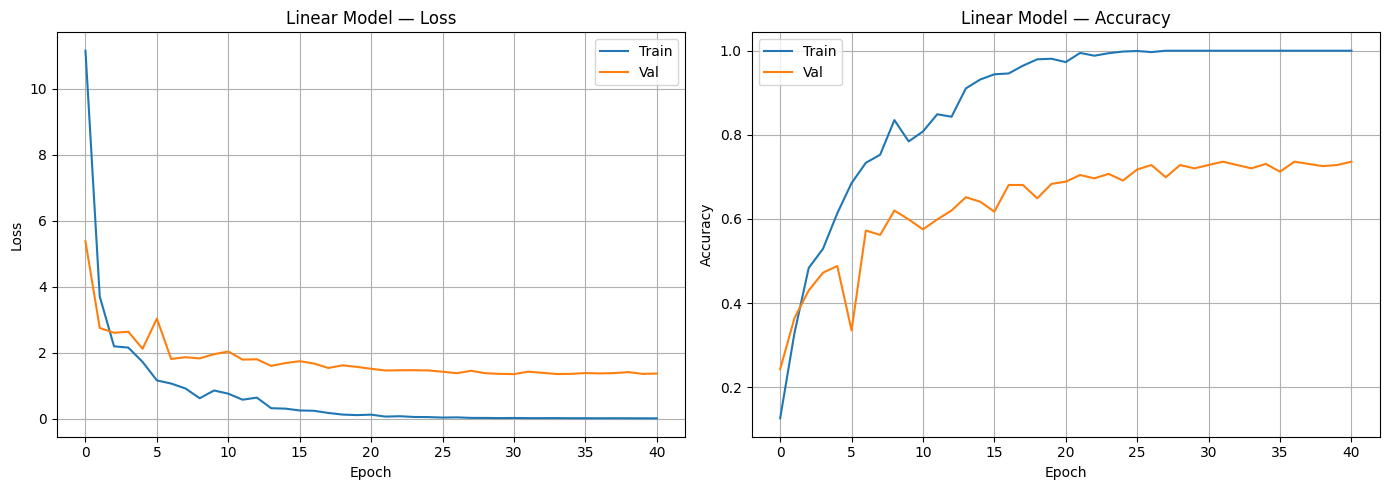

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Train')
axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Linear Model — Loss'); axes[0].legend(); axes[0].grid(True)

axes[1].plot(history.history['accuracy'],     label='Train')
axes[1].plot(history.history['val_accuracy'], label='Val')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Linear Model — Accuracy'); axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'linear_baseline_history.png'), dpi=150, bbox_inches='tight')
plt.show()

In [9]:
train_loss, train_acc = linear_model.evaluate(train_ds, verbose=0)
val_loss,   val_acc   = linear_model.evaluate(val_ds,   verbose=0)

print(f"Linear Model (baseline):")
print(f"  Train — Loss: {train_loss:.4f}, Acc: {train_acc:.4f}")
print(f"  Val   — Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

Linear Model (baseline):
  Train — Loss: 0.0231, Acc: 1.0000
  Val   — Loss: 1.3544, Acc: 0.7282


## 5. Kaggle submission

Final model trained on all data; embeddings extracted from the Flatten layer → cosine similarity.

In [10]:
LR = 1e-4

all_train_df = pd.read_csv(os.path.join(CLEANED_DIR, 'train_clean.csv'))
print("Building full-train dataset (lazy)...")
all_ds = make_dataset(all_train_df, TRAIN_IMG_DIR, training=True)

final_model = build_linear_model()
final_model.compile(
    optimizer=optimizers.Adam(learning_rate=LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

final_log_dir = os.path.join(LOG_DIR, 'linear_baseline_final', datetime.now().strftime('%Y%m%d-%H%M%S'))
final_hist = final_model.fit(
    all_ds,
    epochs=30,
    callbacks=[callbacks.TensorBoard(log_dir=final_log_dir)],
    verbose=1
)
print(f"Final train acc: {final_hist.history['accuracy'][-1]:.4f}")

Building full-train dataset (lazy)...
Epoch 1/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.1620 - loss: 9.5805 
Epoch 2/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.3842 - loss: 2.9048
Epoch 3/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.5018 - loss: 2.1153
Epoch 4/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.5900 - loss: 1.6957
Epoch 5/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.6797 - loss: 1.4402
Epoch 6/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.6828 - loss: 1.2295
Epoch 7/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.7108 - loss: 1.1623
Epoch 8/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.7636 - loss: 0.9636
Epoch 9/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.7499 - loss: 0.9682
Epoch 10/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.8496 - loss: 0.5473
Epoch 11/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.8454 - loss: 0.5765
Epoch 12/30
60/60 ━━━━━━

In [13]:
inp = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = inp
for layer in final_model.layers[:-1]:
    x = layer(x)
embedding_model = keras.Model(inputs=inp, outputs=x, name='linear_embedding')

test_filenames       = sorted(test_images.keys())
test_array           = np.array([test_images[f] for f in test_filenames])  # 371 imgs — OK
test_embeddings      = embedding_model.predict(test_array, batch_size=BATCH_SIZE, verbose=1)
test_embeddings_norm = normalize(test_embeddings, axis=1)

print(f"Embeddings shape: {test_embeddings_norm.shape}")

fname_to_idx = {fname: i for i, fname in enumerate(test_filenames)}
query_idx    = test_pairs_df['query_image'].map(fname_to_idx).values
gallery_idx  = test_pairs_df['gallery_image'].map(fname_to_idx).values

# Chunks pour éviter l'allocation (137270, 150528) → 77 GiB
CHUNK = 1000
similarities = np.empty(len(query_idx), dtype=np.float32)
for start in range(0, len(query_idx), CHUNK):
    sl = slice(start, start + CHUNK)
    q  = test_embeddings_norm[query_idx[sl]]
    g  = test_embeddings_norm[gallery_idx[sl]]
    similarities[sl] = np.clip((q * g).sum(axis=1), 0, 1)

submission = pd.DataFrame({'row_id': test_pairs_df['row_id'], 'similarity': similarities})
submission_path = os.path.join(SUBMISSION_DIR, 'submission_linear_baseline.csv')
submission.to_csv(submission_path, index=False)
print(f"Saved: {submission_path}")

sample_sub = pd.read_csv(os.path.join(DATA_DIR, 'sample_submission.csv'))
assert list(submission.columns) == list(sample_sub.columns)
assert len(submission) == len(sample_sub)
print("Format OK")
display(submission.head())


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Embeddings shape: (371, 150528)
Saved: c:\Users\Frédéric\Developer\kaggle_jaguar_classification\submissions\submission_linear_baseline.csv
Format OK


,row_id,similarity
0,0,0.890965
1,1,0.843432
2,2,0.863581
3,3,0.888410
4,4,0.899426


## 6. Summary

In [14]:
print("=" * 50)
print("LINEAR MODEL — BASELINE SUMMARY")
print("=" * 50)
print(f"""
Architecture  : Flatten -> Dense(31, softmax)
Optimizer     : Adam (lr={LR})
Regularization: none
Augmentation  : none
Epochs        : 50 (early stopping patience=10)

Val accuracy  : {val_acc:.4f}
Val loss      : {val_loss:.4f}

Submission    : submissions/submission_linear_baseline.csv
TensorBoard   : tensorboard --logdir={LOG_DIR}
""")

LINEAR MODEL — BASELINE SUMMARY

Architecture  : Flatten -> Dense(31, softmax)
Optimizer     : Adam (lr=0.0001)
Regularization: none
Augmentation  : none
Epochs        : 50 (early stopping patience=10)

Val accuracy  : 0.7282
Val loss      : 1.3544

Submission    : submissions/submission_linear_baseline.csv
TensorBoard   : tensorboard --logdir=C:\tf\logs

